In [ ]:
import pandas as pd
import os

path = "./data/enrolment/"

files = os.listdir(path)
files[:5]

In [ ]:
file_path = os.path.join(path, files[0])
df = pd.read_csv(file_path)

df.head()


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,02-03-2025,Meghalaya,East Khasi Hills,793121,11,61,37
1,09-03-2025,Karnataka,Bengaluru Urban,560043,14,33,39
2,09-03-2025,Uttar Pradesh,Kanpur Nagar,208001,29,82,12
3,09-03-2025,Uttar Pradesh,Aligarh,202133,62,29,15
4,09-03-2025,Karnataka,Bengaluru Urban,560016,14,16,21


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   date            500000 non-null  object
 1   state           500000 non-null  object
 2   district        500000 non-null  object
 3   pincode         500000 non-null  int64 
 4   age_0_5         500000 non-null  int64 
 5   age_5_17        500000 non-null  int64 
 6   age_18_greater  500000 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 26.7+ MB


In [ ]:
df.shape


(500000, 7)

In [ ]:
df.columns


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')

Number of Aadhaar enrolments for a given
date + state + district + pincode, split by age groups

Columns:

date → time (currently object, probably month)

state, district, pincode → geography

age_0_5, age_5_17, age_18_greater → enrolment counts

In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df[['date', 'year', 'month']].head()


,date,year,month
0,2025-03-02,2025,3
1,2025-03-09,2025,3
2,2025-03-09,2025,3
3,2025-03-09,2025,3
4,2025-03-09,2025,3


In [ ]:
df[['age_0_5', 'age_5_17', 'age_18_greater']].sum()


age_0_5           2020406
age_5_17          1157841
age_18_greater     122779
dtype: int64

In [ ]:
enrolment_district = df.groupby(
    ['state', 'district']
)[['age_0_5', 'age_5_17', 'age_18_greater']].sum().reset_index()

enrolment_district['total_enrolment'] = (
    enrolment_district['age_0_5'] +
    enrolment_district['age_5_17'] +
    enrolment_district['age_18_greater']
)

enrolment_district.head()


,state,district,age_0_5,age_5_17,age_18_greater,total_enrolment
0,100000,100000,0,1,12,13
1,Andaman & Nicobar Islands,Andamans,32,4,0,36
2,Andaman & Nicobar Islands,Nicobars,1,0,0,1
3,Andaman & Nicobar Islands,South Andaman,20,0,0,20
4,Andaman and Nicobar Islands,Nicobar,45,9,0,54


In [ ]:
pincode_count = df.groupby(
    ['state', 'district']
)['pincode'].nunique().reset_index(name='pincode_count')

enrolment_district = enrolment_district.merge(
    pincode_count,
    on=['state', 'district'],
    how='left'
)

enrolment_district['enrolment_intensity'] = (
    enrolment_district['total_enrolment'] /
    enrolment_district['pincode_count']
)

enrolment_district.head()


,state,district,age_0_5,age_5_17,age_18_greater,total_enrolment,pincode_count,enrolment_intensity
0,100000,100000,0,1,12,13,1,13.0
1,Andaman & Nicobar Islands,Andamans,32,4,0,36,6,6.0
2,Andaman & Nicobar Islands,Nicobars,1,0,0,1,1,1.0
3,Andaman & Nicobar Islands,South Andaman,20,0,0,20,5,4.0
4,Andaman and Nicobar Islands,Nicobar,45,9,0,54,4,13.5


In [ ]:
enrolment_district[['total_enrolment', 'pincode_count', 'enrolment_intensity']].describe()


,total_enrolment,pincode_count,enrolment_intensity
count,1050.000000,1050.000000,1050.000000
mean,3143.834286,26.449524,160.340937
std,4456.068918,26.739320,276.423143
min,1.000000,1.000000,1.000000
25%,303.250000,7.000000,17.238971
50%,1419.500000,18.000000,63.745370
75%,3976.500000,36.000000,191.312500
max,34278.000000,166.000000,3766.000000


In [ ]:
#Classify Enrolment Hotspots
high_threshold = enrolment_district['enrolment_intensity'].quantile(0.75)
low_threshold = enrolment_district['enrolment_intensity'].quantile(0.25)

def enrolment_category(x):
    if x >= high_threshold:
        return 'High Enrolment Demand'
    elif x < low_threshold:
        return 'Low Enrolment Demand'
    else:
        return 'Medium Enrolment Demand'

enrolment_district['enrolment_category'] = enrolment_district['enrolment_intensity'].apply(enrolment_category)

enrolment_district['enrolment_category'].value_counts()


enrolment_category
Medium Enrolment Demand    524
Low Enrolment Demand       263
High Enrolment Demand      263
Name: count, dtype: int64

In [ ]:
demo_path = "./data/demographic/"
demo_files = os.listdir(demo_path)

demo_file = os.path.join(demo_path, demo_files[0])
demo_df = pd.read_csv(demo_file)

demo_df.head()


,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,01-03-2025,Uttar Pradesh,Gorakhpur,273213,49,529
1,01-03-2025,Andhra Pradesh,Chittoor,517132,22,375
2,01-03-2025,Gujarat,Rajkot,360006,65,765
3,01-03-2025,Andhra Pradesh,Srikakulam,532484,24,314
4,01-03-2025,Rajasthan,Udaipur,313801,45,785


In [ ]:
demo_df.info()
demo_df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   date           500000 non-null  object
 1   state          500000 non-null  object
 2   district       500000 non-null  object
 3   pincode        500000 non-null  int64 
 4   demo_age_5_17  500000 non-null  int64 
 5   demo_age_17_   500000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 22.9+ MB


Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')

In [ ]:
#PHASE 2 — UPDATE INTENSITY (DEMOGRAPHIC)
demo_district = demo_df.groupby(
    ['state', 'district']
)[['demo_age_5_17', 'demo_age_17_']].sum().reset_index()

demo_district['total_demo_updates'] = (
    demo_district['demo_age_5_17'] +
    demo_district['demo_age_17_']
)

demo_district.head()


,state,district,demo_age_5_17,demo_age_17_,total_demo_updates
0,Andaman & Nicobar Islands,Andamans,2,172,174
1,Andaman & Nicobar Islands,Nicobars,0,2,2
2,Andaman & Nicobar Islands,South Andaman,4,79,83
3,Andaman and Nicobar Islands,Nicobar,4,60,64
4,Andaman and Nicobar Islands,North And Middle Andaman,44,628,672


In [ ]:
demo_pincode_count = demo_df.groupby(
    ['state', 'district']
)['pincode'].nunique().reset_index(name='pincode_count')

demo_district = demo_district.merge(
    demo_pincode_count,
    on=['state', 'district'],
    how='left'
)

demo_district['demo_update_intensity'] = (
    demo_district['total_demo_updates'] /
    demo_district['pincode_count']
)

demo_district.head()


,state,district,demo_age_5_17,demo_age_17_,total_demo_updates,pincode_count,demo_update_intensity
0,Andaman & Nicobar Islands,Andamans,2,172,174,7,24.857143
1,Andaman & Nicobar Islands,Nicobars,0,2,2,1,2.000000
2,Andaman & Nicobar Islands,South Andaman,4,79,83,5,16.600000
3,Andaman and Nicobar Islands,Nicobar,4,60,64,4,16.000000
4,Andaman and Nicobar Islands,North And Middle Andaman,44,628,672,7,96.000000


In [ ]:
demo_district[['total_demo_updates', 'pincode_count', 'demo_update_intensity']].describe()


,total_demo_updates,pincode_count,demo_update_intensity
count,1042.000000,1042.000000,1042.000000
mean,13718.834933,28.255278,545.157424
std,18494.853048,27.556354,872.488839
min,1.000000,1.000000,1.000000
25%,795.500000,8.250000,67.625000
50%,7386.500000,20.000000,271.493974
75%,18169.250000,39.000000,772.704113
max,137575.000000,170.000000,12985.200000


In [ ]:
#PHASE 3 — DISTRICT HOTSPOT CLASSIFICATION (CORE SOLUTION)
high_update_threshold = demo_district['demo_update_intensity'].quantile(0.75)
low_update_threshold = demo_district['demo_update_intensity'].quantile(0.25)

def update_category(x):
    if x >= high_update_threshold:
        return 'High Update Demand'
    elif x < low_update_threshold:
        return 'Low Update Demand'
    else:
        return 'Medium Update Demand'

demo_district['update_category'] = demo_district['demo_update_intensity'].apply(update_category)

demo_district['update_category'].value_counts()


update_category
Medium Update Demand    520
Low Update Demand       261
High Update Demand      261
Name: count, dtype: int64

In [ ]:
district_demand = enrolment_district.merge(
    demo_district[['state', 'district', 'update_category']],
    on=['state', 'district'],
    how='inner'
)

district_demand[['enrolment_category', 'update_category']].head()


,enrolment_category,update_category
0,Low Enrolment Demand,Low Update Demand
1,Low Enrolment Demand,Low Update Demand
2,Low Enrolment Demand,Low Update Demand
3,Low Enrolment Demand,Low Update Demand
4,Low Enrolment Demand,Medium Update Demand


In [ ]:
def demand_zone(row):
    if row['enrolment_category'] == 'High Enrolment Demand' and row['update_category'] == 'High Update Demand':
        return 'Zone 1: High Enrolment & High Update'
    elif row['enrolment_category'] == 'High Enrolment Demand' and row['update_category'] != 'High Update Demand':
        return 'Zone 2: Enrolment Heavy'
    elif row['enrolment_category'] != 'High Enrolment Demand' and row['update_category'] == 'High Update Demand':
        return 'Zone 3: Update Heavy'
    else:
        return 'Zone 4: Low Demand'

district_demand['demand_zone'] = district_demand.apply(demand_zone, axis=1)

district_demand['demand_zone'].value_counts()


demand_zone
Zone 4: Low Demand                      674
Zone 1: High Enrolment & High Update    165
Zone 3: Update Heavy                     96
Zone 2: Enrolment Heavy                  72
Name: count, dtype: int64

In [ ]:
#
bio_path = "./data/biometric/"
bio_files = os.listdir(bio_path)

bio_file = os.path.join(bio_path, bio_files[0])
bio_df = pd.read_csv(bio_file)

bio_df.head()


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [ ]:
bio_df.info()
bio_df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          500000 non-null  object
 1   state         500000 non-null  object
 2   district      500000 non-null  object
 3   pincode       500000 non-null  int64 
 4   bio_age_5_17  500000 non-null  int64 
 5   bio_age_17_   500000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 22.9+ MB


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [ ]:
bio_district = bio_df.groupby(
    ['state', 'district']
)[['bio_age_5_17', 'bio_age_17_']].sum().reset_index()

bio_district['total_bio_updates'] = (
    bio_district['bio_age_5_17'] +
    bio_district['bio_age_17_']
)

bio_district.head()


,state,district,bio_age_5_17,bio_age_17_,total_bio_updates
0,Andaman & Nicobar Islands,Andamans,161,1122,1283
1,Andaman & Nicobar Islands,Nicobars,1,0,1
2,Andaman & Nicobar Islands,South Andaman,20,78,98
3,Andaman and Nicobar Islands,Nicobar,611,637,1248
4,Andaman and Nicobar Islands,North And Middle Andaman,2547,2228,4775


In [ ]:
bio_pincode_count = bio_df.groupby(
    ['state', 'district']
)['pincode'].nunique().reset_index(name='pincode_count')

bio_district = bio_district.merge(
    bio_pincode_count,
    on=['state', 'district'],
    how='left'
)

bio_district['bio_update_intensity'] = (
    bio_district['total_bio_updates'] /
    bio_district['pincode_count']
)

bio_district.head()


,state,district,bio_age_5_17,bio_age_17_,total_bio_updates,pincode_count,bio_update_intensity
0,Andaman & Nicobar Islands,Andamans,161,1122,1283,8,160.375000
1,Andaman & Nicobar Islands,Nicobars,1,0,1,1,1.000000
2,Andaman & Nicobar Islands,South Andaman,20,78,98,5,19.600000
3,Andaman and Nicobar Islands,Nicobar,611,637,1248,4,312.000000
4,Andaman and Nicobar Islands,North And Middle Andaman,2547,2228,4775,7,682.142857


In [ ]:
bio_district[['total_bio_updates', 'pincode_count', 'bio_update_intensity']].describe()


,total_bio_updates,pincode_count,bio_update_intensity
count,1032.000000,1032.000000,1032.000000
mean,47216.074612,28.039729,1838.685217
std,55245.282109,27.504860,2153.522109
min,1.000000,1.000000,1.000000
25%,2972.250000,8.000000,231.675000
50%,29152.000000,20.000000,1187.219644
75%,71723.750000,38.000000,2764.042885
max,402794.000000,168.000000,21746.800000


In [ ]:
update_district = demo_district.merge(
    bio_district[['state', 'district', 'bio_update_intensity']],
    on=['state', 'district'],
    how='inner'
)

update_district['total_update_intensity'] = (
    update_district['demo_update_intensity'] +
    update_district['bio_update_intensity']
)

update_district[['demo_update_intensity', 'bio_update_intensity', 'total_update_intensity']].head()


,demo_update_intensity,bio_update_intensity,total_update_intensity
0,24.857143,160.375000,185.232143
1,2.000000,1.000000,3.000000
2,16.600000,19.600000,36.200000
3,16.000000,312.000000,328.000000
4,96.000000,682.142857,778.142857


In [ ]:
update_district['total_update_intensity'].describe()


count     1013.000000
mean      2433.408471
std       2913.383073
min          2.000000
25%        398.883333
50%       1562.418208
75%       3619.741026
max      34732.000000
Name: total_update_intensity, dtype: float64

In [ ]:
high_update_thr = update_district['total_update_intensity'].quantile(0.75)
low_update_thr = update_district['total_update_intensity'].quantile(0.25)

def final_update_category(x):
    if x >= high_update_thr:
        return 'High Update Demand'
    elif x < low_update_thr:
        return 'Low Update Demand'
    else:
        return 'Medium Update Demand'

update_district['final_update_category'] = update_district['total_update_intensity'].apply(final_update_category)

update_district['final_update_category'].value_counts()


final_update_category
Medium Update Demand    506
High Update Demand      254
Low Update Demand       253
Name: count, dtype: int64

In [ ]:
final_district_demand = enrolment_district.merge(
    update_district[['state', 'district', 'final_update_category']],
    on=['state', 'district'],
    how='inner'
)

final_district_demand[['enrolment_category', 'final_update_category']].head()


,enrolment_category,final_update_category
0,Low Enrolment Demand,Low Update Demand
1,Low Enrolment Demand,Low Update Demand
2,Low Enrolment Demand,Low Update Demand
3,Low Enrolment Demand,Low Update Demand
4,Low Enrolment Demand,Medium Update Demand


In [ ]:
def final_demand_zone(row):
    if row['enrolment_category'] == 'High Enrolment Demand' and row['final_update_category'] == 'High Update Demand':
        return 'Zone A: High Enrolment & High Update'
    elif row['enrolment_category'] == 'High Enrolment Demand':
        return 'Zone B: Enrolment Heavy'
    elif row['final_update_category'] == 'High Update Demand':
        return 'Zone C: Update Heavy'
    else:
        return 'Zone D: Low Demand'

final_district_demand['final_demand_zone'] = final_district_demand.apply(final_demand_zone, axis=1)

final_district_demand['final_demand_zone'].value_counts()


final_demand_zone
Zone D: Low Demand                      671
Zone A: High Enrolment & High Update    163
Zone C: Update Heavy                     91
Zone B: Enrolment Heavy                  73
Name: count, dtype: int64

In [ ]:
insight_table = final_district_demand.groupby('final_demand_zone').agg(
    district_count=('district', 'count'),
    avg_enrolment_intensity=('enrolment_intensity', 'mean'),
    avg_update_intensity=('final_update_category', 'count')
).reset_index()

insight_table


,final_demand_zone,district_count,avg_enrolment_intensity,avg_update_intensity
0,Zone A: High Enrolment & High Update,163,444.605262,163
1,Zone B: Enrolment Heavy,73,492.039028,73
2,Zone C: Update Heavy,91,125.912034,91
3,Zone D: Low Demand,671,45.369756,671


In [ ]:
sample_districts = final_district_demand.groupby(
    'final_demand_zone'
).head(5)[
    ['state', 'district', 'enrolment_intensity', 'final_demand_zone']
]

sample_districts


,state,district,enrolment_intensity,final_demand_zone
0,Andaman & Nicobar Islands,Andamans,6.000000,Zone D: Low Demand
1,Andaman & Nicobar Islands,Nicobars,1.000000,Zone D: Low Demand
2,Andaman & Nicobar Islands,South Andaman,4.000000,Zone D: Low Demand
3,Andaman and Nicobar Islands,Nicobar,13.500000,Zone D: Low Demand
4,Andaman and Nicobar Islands,North And Middle Andaman,7.857143,Zone D: Low Demand
61,Arunachal Pradesh,Longding,264.666667,Zone B: Enrolment Heavy
78,Assam,Barpeta,435.480000,Zone B: Enrolment Heavy
81,Assam,Cachar,239.379310,Zone B: Enrolment Heavy
83,Assam,Chirang,198.846154,Zone B: Enrolment Heavy
84,Assam,Darrang,270.117647,Zone B: Enrolment Heavy


<Axes: title={'center': 'District-wise Aadhaar Service Demand Zones'}, xlabel='final_demand_zone'>

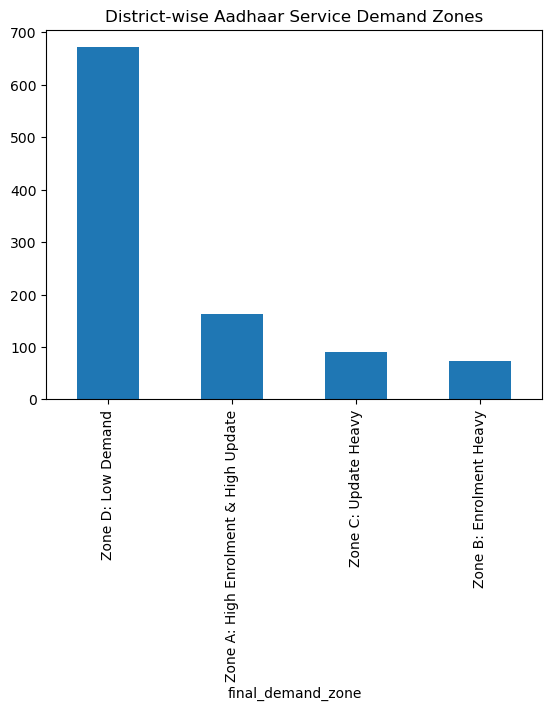

In [ ]:
final_district_demand['final_demand_zone'].value_counts().plot(
    kind='bar',
    title='District-wise Aadhaar Service Demand Zones'
)


<Axes: title={'center': 'Distribution of Enrolment Intensity'}, ylabel='Frequency'>

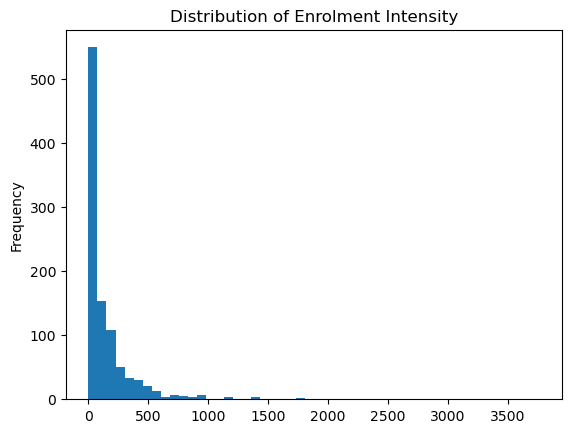

In [ ]:
final_district_demand['enrolment_intensity'].plot(
    kind='hist',
    bins=50,
    title='Distribution of Enrolment Intensity'
)


<Axes: title={'center': 'Distribution of Update Intensity'}, ylabel='Frequency'>

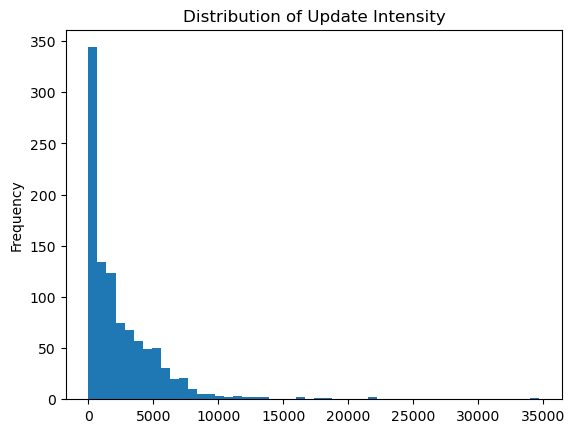

In [ ]:
update_district['total_update_intensity'].plot(
    kind='hist',
    bins=50,
    title='Distribution of Update Intensity'
)


Predictive Indicators:
Districts classified as “High Update Demand” act as predictive indicators of sustained Aadhaar service load. These districts are likely to require higher staffing, more frequent biometric updates, and permanent service infrastructure in the future.